# Modelling Cancellation 
## Using ML models: Logistic Regression, XG Boost, Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load data

In [ ]:
hotel_bookings = pd.read_csv('/Users/kiepeeh1/Documents/00 Working Projects/Hotel Data Analytics/Hotel Analytics/Data/Processed_Data/final_hotel_bookings.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../Data/Processed_Data/final_hotel_bookings.csv'

In [3]:
hotel_bookings.head(10)

,hotel,arrival_date,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,booking_changes_flag,total_nights,revenue,total_adr,booking_time_flag,weekend_ratio,expected_loss,booking_value,booking_urgency,sameDay_booking
0,Resort Hotel,2015-07-01,0,342,2015,July,27,1,0,0,...,True,0,0.0,0.0,90+,0.0,0.0,Low Value,0.00,0
1,Resort Hotel,2015-07-01,0,737,2015,July,27,1,0,0,...,True,0,0.0,0.0,90+,0.0,0.0,Low Value,0.00,0
2,Resort Hotel,2015-07-01,0,7,2015,July,27,1,0,1,...,False,1,75.0,75.0,0-7,0.0,0.0,Low Value,0.12,0
3,Resort Hotel,2015-07-01,0,13,2015,July,27,1,0,1,...,False,1,75.0,75.0,8-30,0.0,0.0,Low Value,0.07,0
4,Resort Hotel,2015-07-01,0,14,2015,July,27,1,0,2,...,False,2,196.0,196.0,8-30,0.0,0.0,Moderate Value,0.07,0
5,Resort Hotel,2015-07-01,0,0,2015,July,27,1,0,2,...,False,2,214.0,214.0,0-7,0.0,0.0,Moderate Value,1.00,1
6,Resort Hotel,2015-07-01,0,9,2015,July,27,1,0,2,...,False,2,206.0,206.0,8-30,0.0,0.0,Moderate Value,0.10,0
7,Resort Hotel,2015-07-01,1,85,2015,July,27,1,0,3,...,False,3,246.0,246.0,31-90,0.0,246.0,Moderate Value,0.01,0
8,Resort Hotel,2015-07-01,1,75,2015,July,27,1,0,3,...,False,3,316.5,316.5,31-90,0.0,316.5,High Value,0.01,0
9,Resort Hotel,2015-07-01,1,23,2015,July,27,1,0,4,...,False,4,492.0,492.0,8-30,0.0,492.0,High Value,0.04,0


In [4]:
hotel_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   hotel                      87396 non-null  object 
 1   arrival_date               87396 non-null  object 
 2   is_canceled                87396 non-null  int64  
 3   lead_time                  87396 non-null  int64  
 4   arrival_date_year          87396 non-null  int64  
 5   arrival_date_month         87396 non-null  object 
 6   arrival_date_week_number   87396 non-null  int64  
 7   arrival_date_day_of_month  87396 non-null  int64  
 8   stays_in_weekend_nights    87396 non-null  int64  
 9   stays_in_week_nights       87396 non-null  int64  
 10  adults                     87396 non-null  int64  
 11  meal                       87396 non-null  object 
 12  country                    86944 non-null  object 
 13  market_segment             87396 non-null  obj

In [14]:
# convert 'is_canceled' column to categorical type
hotel_bookings['is_canceled'] = hotel_bookings['is_canceled'].astype('category')    
# convert all Dtype == 'object' columns to categorical type
for col in hotel_bookings.select_dtypes(include='object').columns:
    hotel_bookings[col] = hotel_bookings[col].astype('category')

In [6]:
hotel_bookings[['lead_time', 'adr', 'revenue']].describe()

,lead_time,adr,revenue
count,87396.000000,87396.000000,87396.000000
mean,79.891368,106.337246,394.307970
std,86.052325,55.013953,369.448748
min,0.000000,-6.380000,-63.800000
25%,11.000000,72.000000,152.475000
50%,49.000000,98.100000,299.000000
75%,125.000000,134.000000,503.200000
max,737.000000,5400.000000,7590.000000


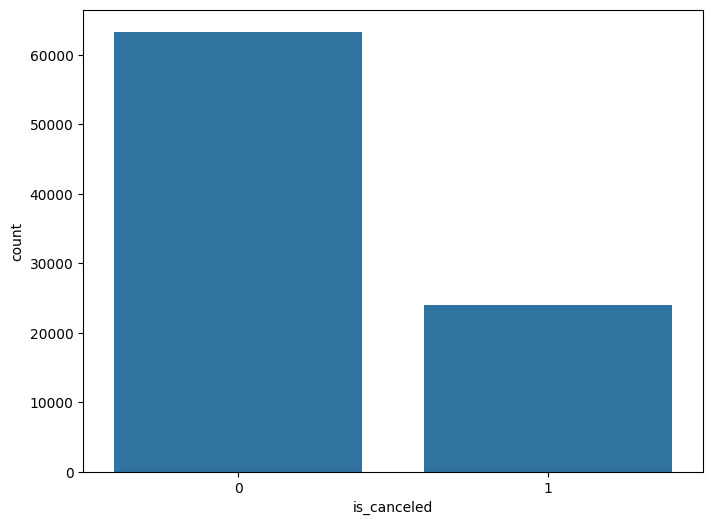

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(x='is_canceled', data=hotel_bookings)
plt.show()

# Feature Engineering

In [26]:
# split the data into features and target variable
feature_cols = [
    'lead_time', 'market_segment', 'distribution_channel', 'customer_type',
    'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'hotel',
    'deposit_type', 'arrival_date_month', 'arrival_date_week_number'
]
# ensure this only apply to categorical columns
X = pd.get_dummies(hotel_bookings[feature_cols], drop_first=False)
y = hotel_bookings['is_canceled']

In [27]:
# Split X and y data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 19)

In [28]:
# Model Development and Prediction
from sklearn.linear_model import LogisticRegression

# initialize the logistic regression model
logreg = LogisticRegression(max_iter=5000)

# fit model with training data
logreg.fit(X_train, y_train)

# make predictions on the test data
logreg_pred = logreg.predict(X_test)

/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

In [29]:
import sklearn.metrics as metrics

logreg_accuracy = metrics.accuracy_score(y_test, logreg_pred)
print("Logistic Regression Accuracy:", logreg_accuracy)

cnf_matrix = metrics.confusion_matrix(y_test, logreg_pred)
cnf_matrix_df = pd.DataFrame(cnf_matrix, index = ['Not Canceled', 'Canceled'], 
columns = ['Predicted Not Canceled', 'Predicted Canceled'])
cnf_matrix_df

Logistic Regression Accuracy: 0.7460620160951982


,Predicted Not Canceled,Predicted Canceled
Not Canceled,18317,719
Canceled,5939,1244


In [22]:
from sklearn.metrics import classification_report

target_names = ['Not Canceled', 'Canceled']
print(classification_report(y_test, logreg_pred, target_names=target_names))

              precision    recall  f1-score   support

Not Canceled       0.76      0.96      0.85     19036
    Canceled       0.63      0.18      0.27      7183

    accuracy                           0.75     26219
   macro avg       0.69      0.57      0.56     26219
weighted avg       0.72      0.75      0.69     26219



In [33]:
# Merge X_test, actual labels, model predictions, and probability columns and ensure these columns are first in the DataFrame

logreg_proba = pd.DataFrame(
    logreg.predict_proba(X_test),
    columns=['pred_0', 'pred_1'],
    index=X_test.index
)

prediction_df = X_test.copy()
prediction_df['actual'] = y_test
prediction_df['predicted'] = logreg_pred
prediction_df = prediction_df.join(logreg_proba)



# ensure these columns are first in the DataFrame
cols = ['actual', 'predicted', 'pred_0', 'pred_1']
prediction_df = prediction_df[cols + [col for col in prediction_df.columns if col not in cols]]
prediction_df.head()

/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,actual,predicted,pred_0,pred_1,lead_time,stays_in_week_nights,stays_in_weekend_nights,adr,arrival_date_week_number,market_segment_Aviation,...,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September
23582,0,0,0.872402,0.127598,214,5,2,84.95,40,False,...,False,False,False,False,False,False,False,False,False,True
48954,1,0,0.657232,0.342768,9,2,0,180.00,18,False,...,False,False,False,False,False,False,True,False,False,False
35355,1,0,0.931484,0.068516,3,2,2,0.00,36,False,...,False,False,False,False,False,False,False,False,False,True
69944,0,0,0.663335,0.336665,212,3,1,129.65,40,False,...,False,False,False,False,False,False,False,False,False,True
62423,0,0,0.591254,0.408746,102,1,0,159.30,21,False,...,False,False,False,False,False,False,True,False,False,False


In [44]:
prediction_df['expected_revenue'] = prediction_df['adr']* (prediction_df['stays_in_week_nights'] + prediction_df['stays_in_weekend_nights'])
prediction_df['proba_loss'] = prediction_df['pred_1'] * prediction_df['expected_revenue']

In [45]:
prediction_df[['actual', 'predicted', 'pred_0', 'pred_1', 'expected_revenue', 'proba_loss']].head()

,actual,predicted,pred_0,pred_1,expected_revenue,proba_loss
23582,0,0,0.872402,0.127598,594.65,75.875946
48954,1,0,0.657232,0.342768,360.00,123.396476
35355,1,0,0.931484,0.068516,0.00,0.000000
69944,0,0,0.663335,0.336665,518.60,174.594303
62423,0,0,0.591254,0.408746,159.30,65.113249


In [ ]:
# scatter plot of expected_revenue vs proba_loss, colored by actual cancellation
plt.figure(figsize=(10, 6))
df = prediction_df.copy()

# map actual (0/1) to readable labels
hue = df['actual'].astype(int).map({0: 'Not Canceled', 1: 'Canceled'})

# limit axes to 99th percentile to reduce extreme outliers for a clearer view
x_max = df['expected_revenue'].quantile(0.99)
y_max = df['proba_loss'].quantile(0.99)

sns.scatterplot(data=df, x='expected_revenue', y='proba_loss', hue=hue, alpha=0.6, s=30)
plt.xlim(0, x_max)
plt.ylim(0, y_max)
plt.xlabel('Expected Revenue')
plt.ylabel('Probability-weighted Loss (proba_loss)')
plt.title('Expected Revenue vs Probability-weighted Loss (colored by actual cancellation)')
plt.legend(title='Actual')
plt.grid(True)
plt.show()

In [34]:
prediction_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26219 entries, 23582 to 56065
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   actual                          26219 non-null  category
 1   predicted                       26219 non-null  int64   
 2   pred_0                          26219 non-null  float64 
 3   pred_1                          26219 non-null  float64 
 4   lead_time                       26219 non-null  int64   
 5   stays_in_week_nights            26219 non-null  int64   
 6   stays_in_weekend_nights         26219 non-null  int64   
 7   adr                             26219 non-null  float64 
 8   arrival_date_week_number        26219 non-null  int64   
 9   market_segment_Aviation         26219 non-null  bool    
 10  market_segment_Complementary    26219 non-null  bool    
 11  market_segment_Corporate        26219 non-null  bool    
 12  market_segment_Dire

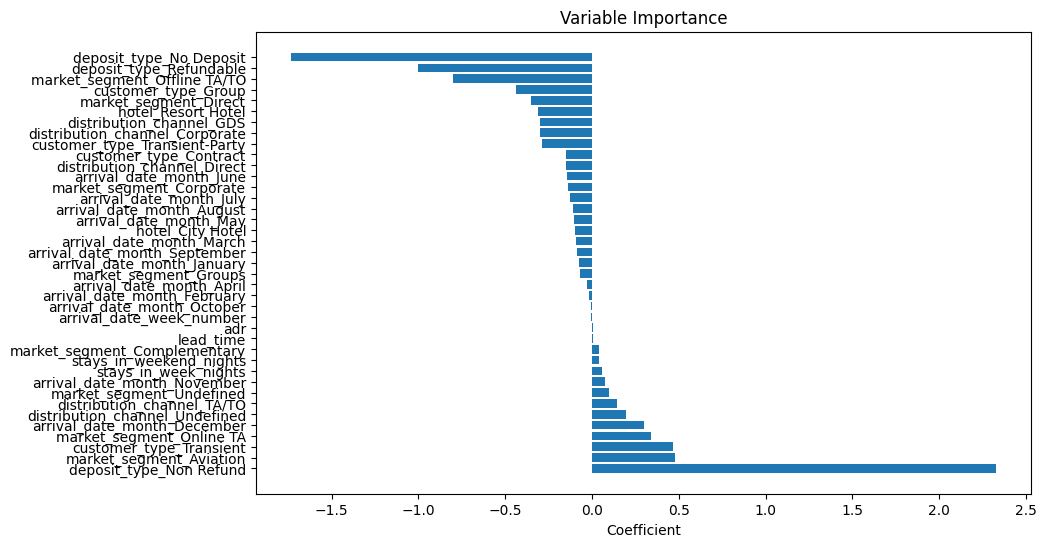

In [35]:
# show variable importance using the coefficients from the logistic regression model
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'coefficient': logreg.coef_[0]
})
importance_df = importance_df.sort_values('coefficient', ascending=False)
importance_df

# plot it
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['coefficient'])
plt.xlabel('Coefficient')
plt.title('Variable Importance')
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

feature_cols = [
    'lead_time', 'market_segment', 'distribution_channel', 'customer_type',
    'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'hotel',
    'deposit_type', 'arrival_date_month', 'arrival_date_week_number'
]

num_cols = ['lead_time', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'arrival_date_week_number']
cat_cols = [c for c in feature_cols if c not in num_cols]

X = hotel_bookings[feature_cols]
y = hotel_bookings['is_canceled'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=19
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

model = LogisticRegression(max_iter=5000, class_weight='balanced')

pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', model)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

# Evaluate the model
model_accuracy = metrics.accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", model_accuracy) 
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix_df = pd.DataFrame(cnf_matrix, index = ['Not Canceled', 'Canceled'], 
columns = ['Predicted Not Canceled', 'Predicted Canceled']) 
cnf_matrix_df

# classification report
target_names = ['Not Canceled', 'Canceled']
print(classification_report(y_test, y_pred, target_names=target_names)) 

Logistic Regression Accuracy: 0.6423585949120867
              precision    recall  f1-score   support

Not Canceled       0.86      0.61      0.71     19036
    Canceled       0.41      0.73      0.53      7183

    accuracy                           0.64     26219
   macro avg       0.64      0.67      0.62     26219
weighted avg       0.74      0.64      0.66     26219

